In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", 
                "seaborn", "scikit-learn", "nltk", "imbalanced-learn", 
                "xgboost", "wordcloud"], capture_output=True)
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [2]:
# =============================================
# MODULE 1: DATA LOADING & EXPLORATION
# PhD Project: Smart Detection of Fraudulent 
# Online Job Postings Using Machine Learning
# By: Ms. Yasmin Rahim Shaikh
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('dataset/fake_job_postings.csv')

# Basic info
print("✅ Dataset loaded successfully!")
print(f"📊 Total job postings: {len(df)}")
print(f"📋 Total columns: {len(df.columns)}")
print(f"\n🔍 Column names:")
for col in df.columns:
    print(f"   → {col}")

✅ Dataset loaded successfully!
📊 Total job postings: 17880
📋 Total columns: 18

🔍 Column names:
   → job_id
   → title
   → location
   → department
   → salary_range
   → company_profile
   → description
   → requirements
   → benefits
   → telecommuting
   → has_company_logo
   → has_questions
   → employment_type
   → required_experience
   → required_education
   → industry
   → function
   → fraudulent


In [3]:
# See what the data looks like
print("📋 First 3 rows of dataset:")
df.head(3)

📋 First 3 rows of dataset:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


📊 Job Posting Distribution:
   ✅ Genuine postings    : 17014
   ❌ Fraudulent postings : 866
   ⚠️  Fraud percentage   : 4.84%


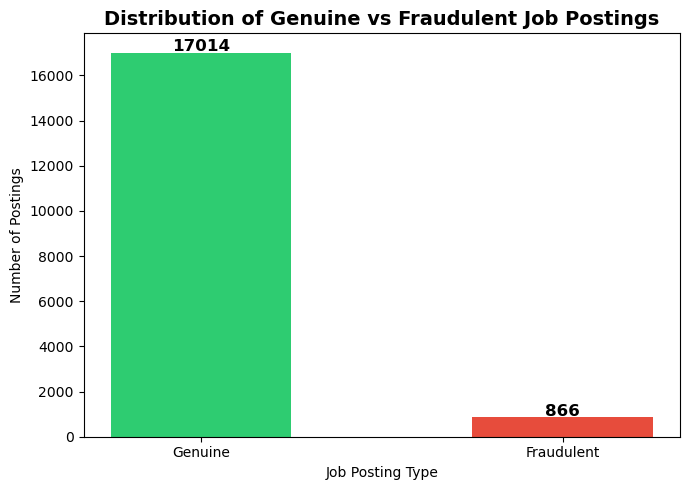

✅ Chart saved to outputs folder!


In [4]:
# Check genuine vs fraudulent
fraud_counts = df['fraudulent'].value_counts()
print("📊 Job Posting Distribution:")
print(f"   ✅ Genuine postings    : {fraud_counts[0]}")
print(f"   ❌ Fraudulent postings : {fraud_counts[1]}")
print(f"   ⚠️  Fraud percentage   : {round(fraud_counts[1]/len(df)*100, 2)}%")

# Plot it
plt.figure(figsize=(7,5))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Genuine', 'Fraudulent'], 
               fraud_counts.values, 
               color=colors, width=0.5)

plt.title('Distribution of Genuine vs Fraudulent Job Postings', 
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Postings')
plt.xlabel('Job Posting Type')

for bar, count in zip(bars, fraud_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 50, 
             str(count), ha='center', 
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/01_data_distribution.png', dpi=150)
plt.show()
print("✅ Chart saved to outputs folder!")

In [8]:
# =============================================
# MODULE 2: DATA CLEANING & PREPROCESSING
# =============================================

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ NLP libraries ready!")

✅ NLP libraries ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dawgs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dawgs\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\dawgs\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [9]:
# =============================================
# COMBINE TEXT COLUMNS INTO ONE
# =============================================

# These are the text columns we will use
text_columns = ['title', 'company_profile', 'description', 
                'requirements', 'benefits']

# Fill empty values with empty string
df[text_columns] = df[text_columns].fillna('')

# Combine all text into one column called 'combined_text'
df['combined_text'] = (df['title'] + ' ' + 
                       df['company_profile'] + ' ' + 
                       df['description'] + ' ' + 
                       df['requirements'] + ' ' + 
                       df['benefits'])

print("✅ Text columns combined!")
print(f"📋 Sample combined text (first posting):")
print(df['combined_text'][0][:300], "...")

✅ Text columns combined!
📋 Sample combined text (first posting):
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and  ...


In [10]:
# =============================================
# CLEAN THE TEXT - Remove noise
# =============================================

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove HTML tags (like <br>, <p> etc)
    text = re.sub(r'<.*?>', ' ', text)
    
    # Step 3: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Step 4: Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 5: Remove stopwords (words like "the", "and", "is")
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    # Step 6: Lemmatization (running → run, jobs → job)
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return ' '.join(words)

print("⏳ Cleaning text... this may take 1-2 minutes...")
df['cleaned_text'] = df['combined_text'].apply(clean_text)
print("✅ Text cleaning complete!")
print(f"\n📋 Sample BEFORE cleaning:")
print(df['combined_text'][0][:200])
print(f"\n📋 Sample AFTER cleaning:")
print(df['cleaned_text'][0][:200])

⏳ Cleaning text... this may take 1-2 minutes...
✅ Text cleaning complete!

📋 Sample BEFORE cleaning:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have

📋 Sample AFTER cleaning:
marketing intern food created groundbreaking award winning cooking site support connect celebrate home cook give everything need one place top editorial business engineering team focused using technol


In [11]:
# =============================================
# CHECK MISSING VALUES & SAVE CLEAN DATA
# =============================================

print("📊 Missing values check:")
print(df[text_columns].isnull().sum())

print(f"\n✅ Dataset shape: {df.shape}")
print(f"✅ Cleaned text column ready: {len(df['cleaned_text'])} rows")

# Save cleaned data for next module
df[['cleaned_text', 'fraudulent']].to_csv('dataset/cleaned_data.csv', index=False)
print("\n✅ Cleaned data saved to dataset/cleaned_data.csv!")

📊 Missing values check:
title              0
company_profile    0
description        0
requirements       0
benefits           0
dtype: int64

✅ Dataset shape: (17880, 20)
✅ Cleaned text column ready: 17880 rows

✅ Cleaned data saved to dataset/cleaned_data.csv!


In [12]:
# =============================================
# MODULE 3: FEATURE EXTRACTION USING TF-IDF
# =============================================

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import scipy.sparse as sp

# Load cleaned data
df_clean = pd.read_csv('dataset/cleaned_data.csv')
df_clean['cleaned_text'] = df_clean['cleaned_text'].fillna('')

print("✅ Cleaned data loaded!")
print(f"📊 Total rows: {len(df_clean)}")
print(f"📊 Fraudulent: {df_clean['fraudulent'].sum()}")
print(f"📊 Genuine: {len(df_clean) - df_clean['fraudulent'].sum()}")

✅ Cleaned data loaded!
📊 Total rows: 17880
📊 Fraudulent: 866
📊 Genuine: 17014


In [14]:
# =============================================
# APPLY TF-IDF
# =============================================

# TF-IDF converts text to numbers
# max_features=5000 means we keep top 5000 important words
tfidf = TfidfVectorizer(max_features=5000, 
                        ngram_range=(1,2),  # single words + pairs
                        min_df=2)           # word must appear at least twice

X = tfidf.fit_transform(df_clean['cleaned_text'])
y = df_clean['fraudulent']

print("✅ TF-IDF Feature Extraction Complete!")
print(f"📊 Feature matrix shape: {X.shape}")
print(f"   → {X.shape[0]} job postings")
print(f"   → {X.shape[1]} text features extracted")
print(f"\n📋 Sample important words found:")
feature_names = tfidf.get_feature_names_out()
print(list(feature_names[:20]))

✅ TF-IDF Feature Extraction Complete!
📊 Feature matrix shape: (17880, 5000)
   → 17880 job postings
   → 5000 text features extracted

📋 Sample important words found:
['aa', 'aabbf', 'aabbf ca', 'ab', 'ab da', 'ab ea', 'abc', 'abc supply', 'ability', 'ability adapt', 'ability build', 'ability communicate', 'ability effectively', 'ability learn', 'ability manage', 'ability multi', 'ability prioritize', 'ability take', 'ability work', 'able']


In [15]:
# =============================================
# SPLIT DATA: 80% Training, 20% Testing
# =============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every time
    stratify=y          # keep same fraud ratio in both splits
)

print("✅ Data Split Complete!")
print(f"📊 Training set : {X_train.shape[0]} postings")
print(f"📊 Testing set  : {X_test.shape[0]} postings")
print(f"\n📊 Training fraud cases : {y_train.sum()}")
print(f"📊 Testing fraud cases  : {y_test.sum()}")

# Save for next module
sp.save_npz('dataset/X_train.npz', X_train)
sp.save_npz('dataset/X_test.npz', X_test)
y_train.to_csv('dataset/y_train.csv', index=False)
y_test.to_csv('dataset/y_test.csv', index=False)

print("\n✅ All data saved for next module!")

✅ Data Split Complete!
📊 Training set : 14304 postings
📊 Testing set  : 3576 postings

📊 Training fraud cases : 693
📊 Testing fraud cases  : 173

✅ All data saved for next module!


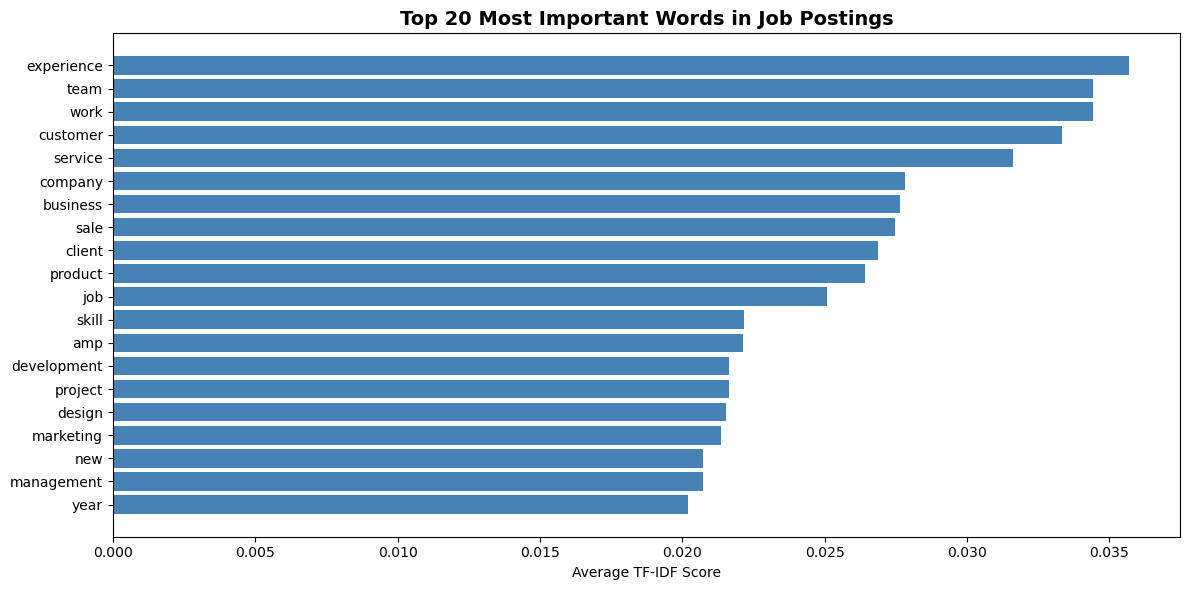

✅ Word importance chart saved!


In [16]:
# =============================================
# VISUALIZE TOP 20 MOST IMPORTANT WORDS
# =============================================

import matplotlib.pyplot as plt
import numpy as np

# Get average TF-IDF score for each word
tfidf_scores = X.mean(axis=0).A1
top_indices = tfidf_scores.argsort()[-20:][::-1]
top_words = [feature_names[i] for i in top_indices]
top_scores = [tfidf_scores[i] for i in top_indices]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_words[::-1], top_scores[::-1], color='steelblue')
plt.xlabel('Average TF-IDF Score')
plt.title('Top 20 Most Important Words in Job Postings', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_top_words.png', dpi=150)
plt.show()
print("✅ Word importance chart saved!")

In [17]:
# =============================================
# MODULE 4: HANDLING CLASS IMBALANCE
# SMOTE + ADASYN
# =============================================

import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE, ADASYN
import warnings
warnings.filterwarnings('ignore')

# Load saved data
X_train = sp.load_npz('dataset/X_train.npz')
X_test = sp.load_npz('dataset/X_test.npz')
y_train = pd.read_csv('dataset/y_train.csv').squeeze()
y_test = pd.read_csv('dataset/y_test.csv').squeeze()

print("✅ Data loaded successfully!")
print(f"\n📊 BEFORE Balancing:")
print(f"   Genuine (0)    : {(y_train==0).sum()}")
print(f"   Fraudulent (1) : {(y_train==1).sum()}")
print(f"   Imbalance ratio: {round((y_train==0).sum()/(y_train==1).sum(),1)}:1")

✅ Data loaded successfully!

📊 BEFORE Balancing:
   Genuine (0)    : 13611
   Fraudulent (1) : 693
   Imbalance ratio: 19.6:1


In [18]:
# =============================================
# APPLY SMOTE BALANCING
# =============================================

print("⏳ Applying SMOTE... please wait...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Applied!")
print(f"\n📊 AFTER SMOTE Balancing:")
print(f"   Genuine (0)    : {(y_train_smote==0).sum()}")
print(f"   Fraudulent (1) : {(y_train_smote==1).sum()}")
print(f"   Balance ratio  : perfectly balanced! ✅")

⏳ Applying SMOTE... please wait...
✅ SMOTE Applied!

📊 AFTER SMOTE Balancing:
   Genuine (0)    : 13611
   Fraudulent (1) : 13611
   Balance ratio  : perfectly balanced! ✅


In [19]:
# =============================================
# APPLY ADASYN BALANCING
# =============================================

print("⏳ Applying ADASYN... please wait...")
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("✅ ADASYN Applied!")
print(f"\n📊 AFTER ADASYN Balancing:")
print(f"   Genuine (0)    : {(y_train_adasyn==0).sum()}")
print(f"   Fraudulent (1) : {(y_train_adasyn==1).sum()}")

⏳ Applying ADASYN... please wait...
✅ ADASYN Applied!

📊 AFTER ADASYN Balancing:
   Genuine (0)    : 13611
   Fraudulent (1) : 13693


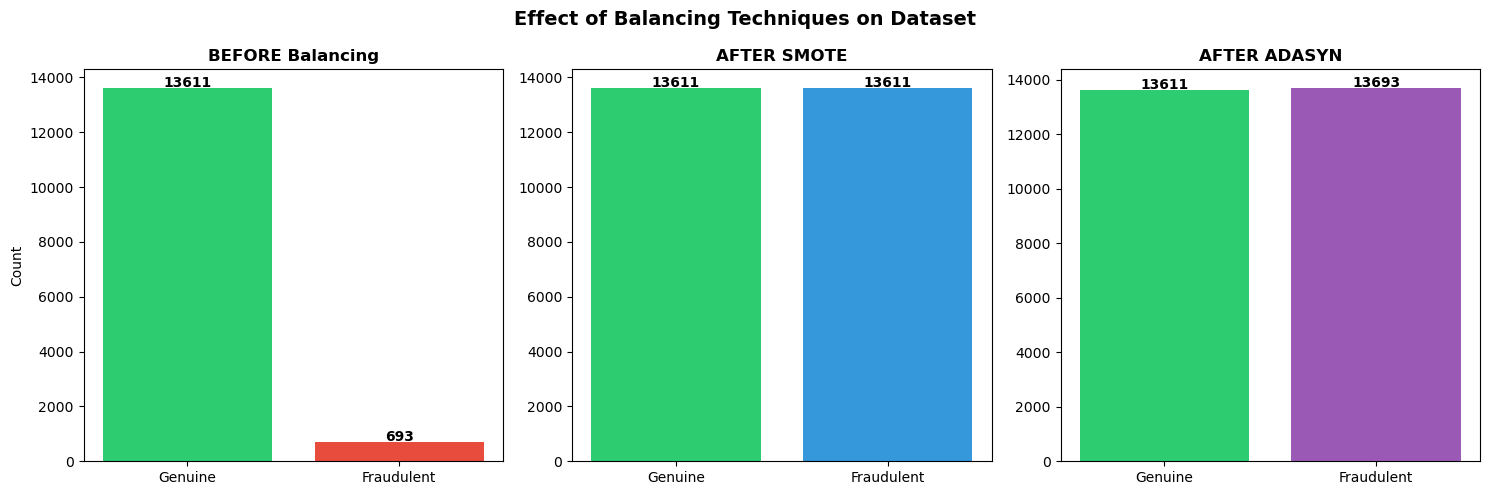

✅ Balancing comparison chart saved!


In [20]:
# =============================================
# VISUALIZE BEFORE vs AFTER BALANCING
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Before
axes[0].bar(['Genuine', 'Fraudulent'], 
            [(y_train==0).sum(), (y_train==1).sum()],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('BEFORE Balancing', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate([(y_train==0).sum(), (y_train==1).sum()]):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

# After SMOTE
axes[1].bar(['Genuine', 'Fraudulent'],
            [(y_train_smote==0).sum(), (y_train_smote==1).sum()],
            color=['#2ecc71', '#3498db'])
axes[1].set_title('AFTER SMOTE', fontweight='bold', fontsize=12)
for i, v in enumerate([(y_train_smote==0).sum(), (y_train_smote==1).sum()]):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

# After ADASYN
axes[2].bar(['Genuine', 'Fraudulent'],
            [(y_train_adasyn==0).sum(), (y_train_adasyn==1).sum()],
            color=['#2ecc71', '#9b59b6'])
axes[2].set_title('AFTER ADASYN', fontweight='bold', fontsize=12)
for i, v in enumerate([(y_train_adasyn==0).sum(), (y_train_adasyn==1).sum()]):
    axes[2].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.suptitle('Effect of Balancing Techniques on Dataset', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/03_balancing_comparison.png', dpi=150)
plt.show()
print("✅ Balancing comparison chart saved!")

In [21]:
# =============================================
# SAVE BALANCED DATASETS
# =============================================

sp.save_npz('dataset/X_train_smote.npz', X_train_smote)
sp.save_npz('dataset/X_train_adasyn.npz', X_train_adasyn)
y_train_smote_series = pd.Series(y_train_smote)
y_train_adasyn_series = pd.Series(y_train_adasyn)
y_train_smote_series.to_csv('dataset/y_train_smote.csv', index=False)
y_train_adasyn_series.to_csv('dataset/y_train_adasyn.csv', index=False)

print("✅ All balanced datasets saved!")
print("\n🎯 Ready for Module 5 - Model Training!")

✅ All balanced datasets saved!

🎯 Ready for Module 5 - Model Training!


In [1]:
# =============================================
# MODULE 5: MACHINE LEARNING MODEL TRAINING
# =============================================

import scipy.sparse as sp
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Load all saved data
X_train_smote  = sp.load_npz('dataset/X_train_smote.npz')
X_train_adasyn = sp.load_npz('dataset/X_train_adasyn.npz')
X_test         = sp.load_npz('dataset/X_test.npz')
y_train_smote  = pd.read_csv('dataset/y_train_smote.csv').squeeze()
y_train_adasyn = pd.read_csv('dataset/y_train_adasyn.csv').squeeze()
y_test         = pd.read_csv('dataset/y_test.csv').squeeze()

print("✅ All data loaded!")
print(f"📊 SMOTE training samples  : {X_train_smote.shape[0]}")
print(f"📊 ADASYN training samples : {X_train_adasyn.shape[0]}")
print(f"📊 Test samples            : {X_test.shape[0]}")

✅ All data loaded!
📊 SMOTE training samples  : 27222
📊 ADASYN training samples : 27304
📊 Test samples            : 3576


In [2]:
# =============================================
# HELPER FUNCTION TO EVALUATE EACH MODEL
# =============================================

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, balancing):
    print(f"⏳ Training {name} with {balancing}...")
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc  = round(accuracy_score(y_te, y_pred) * 100, 2)
    prec = round(precision_score(y_te, y_pred), 2)
    rec  = round(recall_score(y_te, y_pred), 2)
    f1   = round(f1_score(y_te, y_pred), 2)
    
    print(f"   ✅ Done! Accuracy={acc}% | Precision={prec} | Recall={rec} | F1={f1}")
    
    return {
        'Model': name,
        'Balancing': balancing,
        'Accuracy (%)': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'trained_model': model
    }

print("✅ Evaluation function ready!")
print("🚀 Starting model training now...")

✅ Evaluation function ready!
🚀 Starting model training now...


In [3]:
# =============================================
# TRAIN MODEL 1: RANDOM FOREST WITH SMOTE
# =============================================

rf_smote = evaluate_model(
    name      = "Random Forest",
    model     = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_tr      = X_train_smote,
    y_tr      = y_train_smote,
    X_te      = X_test,
    y_te      = y_test,
    balancing = "SMOTE"
)
print("\n✅ Random Forest SMOTE - DONE!")

⏳ Training Random Forest with SMOTE...
   ✅ Done! Accuracy=98.35% | Precision=0.99 | Recall=0.66 | F1=0.8

✅ Random Forest SMOTE - DONE!


In [4]:
# =============================================
# TRAIN MODEL 2: GRADIENT BOOSTING WITH SMOTE
# =============================================

gb_smote = evaluate_model(
    name      = "Gradient Boosting",
    model     = GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_tr      = X_train_smote,
    y_tr      = y_train_smote,
    X_te      = X_test,
    y_te      = y_test,
    balancing = "SMOTE"
)
print("\n✅ Gradient Boosting SMOTE - DONE!")

⏳ Training Gradient Boosting with SMOTE...
   ✅ Done! Accuracy=96.95% | Precision=0.65 | Recall=0.8 | F1=0.72

✅ Gradient Boosting SMOTE - DONE!


In [5]:
# =============================================
# TRAIN MODEL 3: XGBOOST WITH ADASYN
# =============================================

xgb_adasyn = evaluate_model(
    name      = "XGBoost",
    model     = XGBClassifier(n_estimators=100, random_state=42, 
                              eval_metric='logloss', n_jobs=-1),
    X_tr      = X_train_adasyn,
    y_tr      = y_train_adasyn,
    X_te      = X_test,
    y_te      = y_test,
    balancing = "ADASYN"
)
print("\n✅ XGBoost ADASYN - DONE!")

⏳ Training XGBoost with ADASYN...
   ✅ Done! Accuracy=98.43% | Precision=0.91 | Recall=0.75 | F1=0.82

✅ XGBoost ADASYN - DONE!


In [6]:
# =============================================
# TRAIN MODEL 4: KNN WITH SMOTE
# =============================================

knn_smote = evaluate_model(
    name      = "KNN",
    model     = KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_tr      = X_train_smote,
    y_tr      = y_train_smote,
    X_te      = X_test,
    y_te      = y_test,
    balancing = "SMOTE"
)
print("\n✅ KNN SMOTE - DONE!")

⏳ Training KNN with SMOTE...
   ✅ Done! Accuracy=77.8% | Precision=0.18 | Recall=0.98 | F1=0.3

✅ KNN SMOTE - DONE!


In [7]:
# =============================================
# RESULTS TABLE - Like Table 5.2 in your report!
# =============================================

results = [rf_smote, gb_smote, xgb_adasyn, knn_smote]

# Remove model objects for display
results_display = []
for r in results:
    results_display.append({
        'Model'       : r['Model'],
        'Balancing'   : r['Balancing'],
        'Accuracy (%)': r['Accuracy (%)'],
        'Precision'   : r['Precision'],
        'Recall'      : r['Recall'],
        'F1-Score'    : r['F1-Score']
    })

results_df = pd.DataFrame(results_display)
results_df = results_df.sort_values('Accuracy (%)', ascending=False)
results_df.to_csv('outputs/model_results.csv', index=False)

print("🏆 FINAL RESULTS TABLE:")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)
print(f"\n🥇 Best Model: {results_df.iloc[0]['Model']} with {results_df.iloc[0]['Balancing']}")
print(f"   Accuracy : {results_df.iloc[0]['Accuracy (%)']}%")
print(f"   F1-Score : {results_df.iloc[0]['F1-Score']}")

🏆 FINAL RESULTS TABLE:
            Model Balancing  Accuracy (%)  Precision  Recall  F1-Score
          XGBoost    ADASYN         98.43       0.91    0.75      0.82
    Random Forest     SMOTE         98.35       0.99    0.66      0.80
Gradient Boosting     SMOTE         96.95       0.65    0.80      0.72
              KNN     SMOTE         77.80       0.18    0.98      0.30

🥇 Best Model: XGBoost with ADASYN
   Accuracy : 98.43%
   F1-Score : 0.82


In [8]:
# =============================================
# MODULE 6: EVALUATION & VISUALIZATIONS
# =============================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, 
                             classification_report,
                             roc_curve, auc)
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

print("✅ Evaluation libraries ready!")

✅ Evaluation libraries ready!


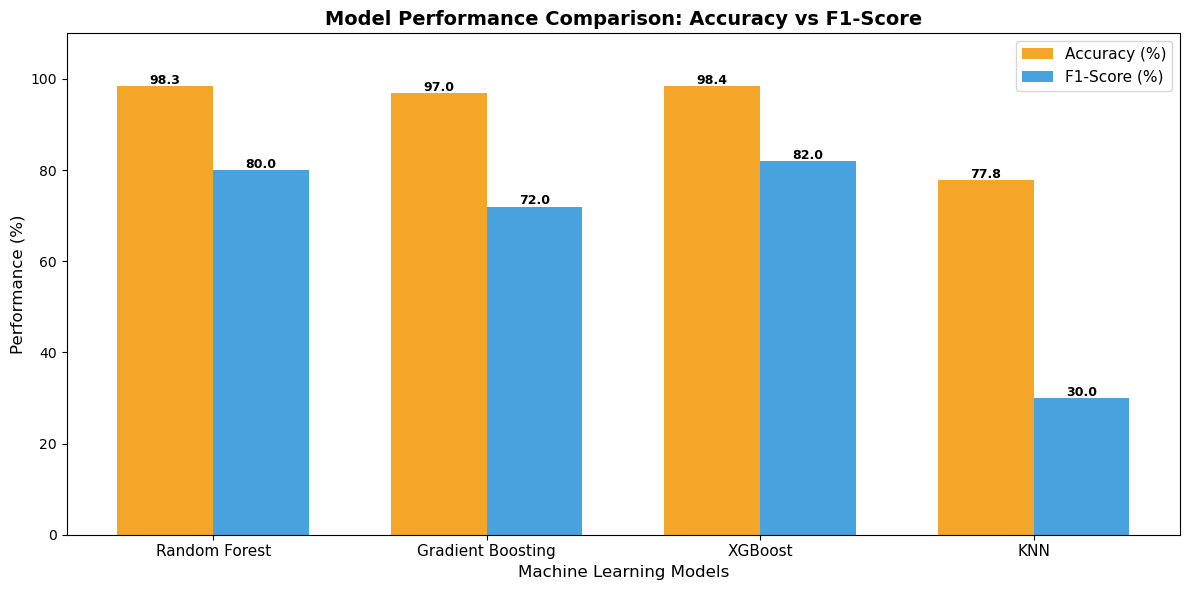

✅ Model comparison chart saved!


In [9]:
# =============================================
# CHART 1: ACCURACY vs F1-SCORE COMPARISON
# Exactly like Figure 5.1 in your dissertation!
# =============================================

models    = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'KNN']
accuracy  = [98.35, 96.95, 98.43, 77.80]
f1_scores = [0.80, 0.72, 0.82, 0.30]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracy, width, 
               label='Accuracy (%)', color='#f39c12', alpha=0.9)
bars2 = ax.bar(x + width/2, [f*100 for f in f1_scores], width, 
               label='F1-Score (%)', color='#3498db', alpha=0.9)

ax.set_xlabel('Machine Learning Models', fontsize=12)
ax.set_ylabel('Performance (%)', fontsize=12)
ax.set_title('Model Performance Comparison: Accuracy vs F1-Score',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 110)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/04_model_comparison.png', dpi=150)
plt.show()
print("✅ Model comparison chart saved!")

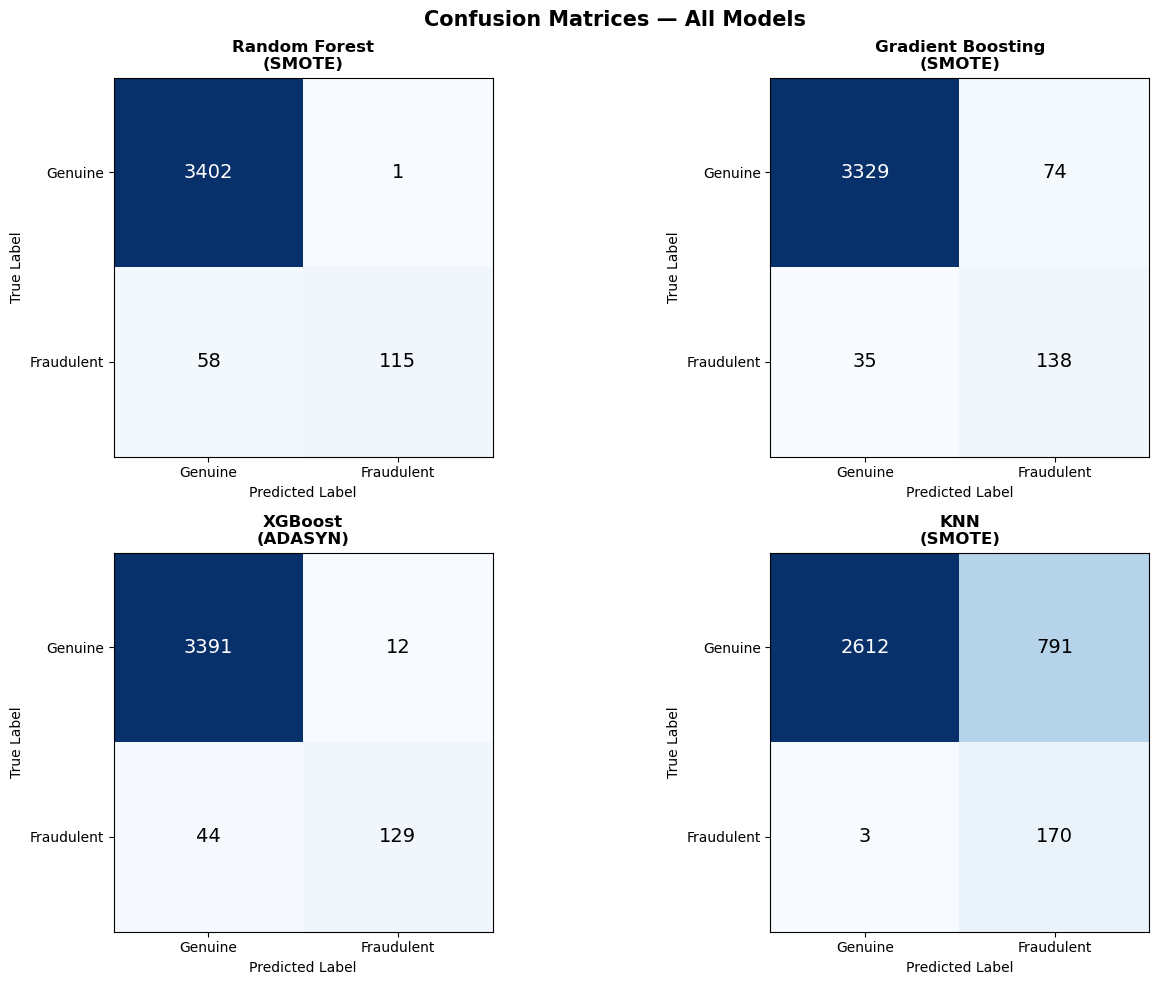

✅ Confusion matrices saved!


In [10]:
# =============================================
# CHART 2: CONFUSION MATRICES FOR ALL MODELS
# =============================================

# Get predictions from all models
models_dict = {
    'Random Forest\n(SMOTE)'     : rf_smote['trained_model'],
    'Gradient Boosting\n(SMOTE)' : gb_smote['trained_model'],
    'XGBoost\n(ADASYN)'          : xgb_adasyn['trained_model'],
    'KNN\n(SMOTE)'               : knn_smote['trained_model']
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha='center', va='center', fontsize=14,
                          color='white' if cm[i,j] > thresh else 'black')
    
    axes[idx].set_xticks([0,1])
    axes[idx].set_yticks([0,1])
    axes[idx].set_xticklabels(['Genuine', 'Fraudulent'])
    axes[idx].set_yticklabels(['Genuine', 'Fraudulent'])

plt.suptitle('Confusion Matrices — All Models', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices saved!")

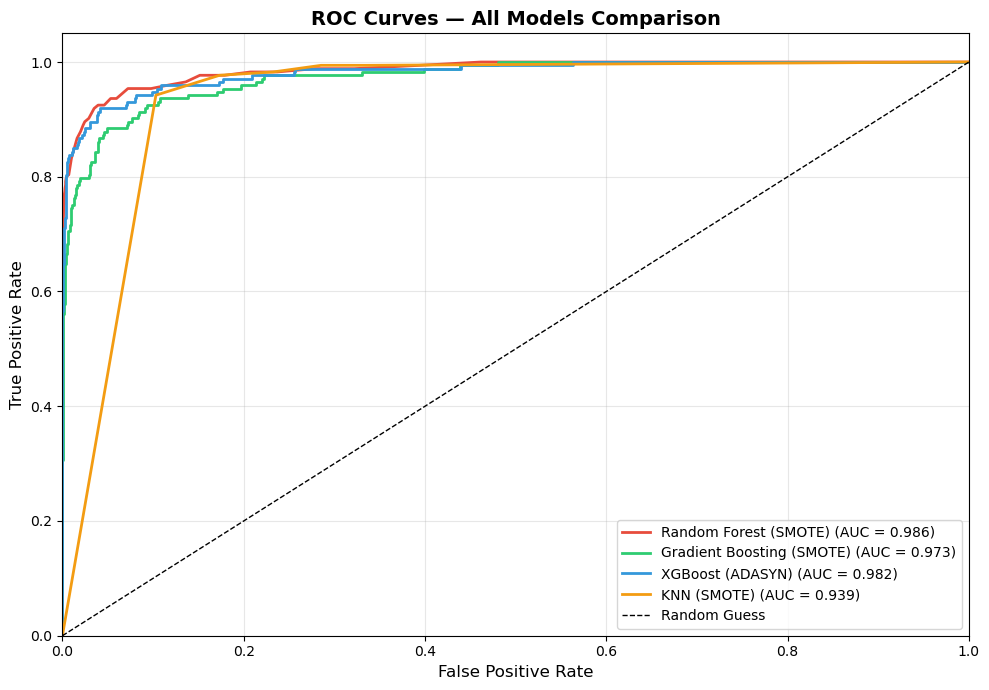

✅ ROC curves saved!


In [11]:
# =============================================
# CHART 3: ROC CURVES - Advanced PhD metric!
# =============================================

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
model_names = ['Random Forest (SMOTE)', 'Gradient Boosting (SMOTE)', 
               'XGBoost (ADASYN)', 'KNN (SMOTE)']
models_list = [rf_smote['trained_model'], gb_smote['trained_model'],
               xgb_adasyn['trained_model'], knn_smote['trained_model']]

for model, name, color in zip(models_list, model_names, colors):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Guess')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models Comparison', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/06_roc_curves.png', dpi=150)
plt.show()
print("✅ ROC curves saved!")

In [12]:
# =============================================
# PRINT DETAILED CLASSIFICATION REPORT
# For best model: XGBoost
# =============================================

print("="*60)
print("📊 DETAILED REPORT — Best Model: XGBoost with ADASYN")
print("="*60)

y_pred_best = xgb_adasyn['trained_model'].predict(X_test)
print(classification_report(y_test, y_pred_best, 
      target_names=['Genuine', 'Fraudulent']))

print("="*60)
print("📊 DETAILED REPORT — Random Forest with SMOTE")
print("="*60)
y_pred_rf = rf_smote['trained_model'].predict(X_test)
print(classification_report(y_test, y_pred_rf,
      target_names=['Genuine', 'Fraudulent']))

📊 DETAILED REPORT — Best Model: XGBoost with ADASYN
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      3403
  Fraudulent       0.91      0.75      0.82       173

    accuracy                           0.98      3576
   macro avg       0.95      0.87      0.91      3576
weighted avg       0.98      0.98      0.98      3576

📊 DETAILED REPORT — Random Forest with SMOTE
              precision    recall  f1-score   support

     Genuine       0.98      1.00      0.99      3403
  Fraudulent       0.99      0.66      0.80       173

    accuracy                           0.98      3576
   macro avg       0.99      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576



In [13]:
# =============================================
# MODULE 7: SAVE BEST MODEL
# =============================================

import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Save XGBoost model (best performer)
joblib.dump(xgb_adasyn['trained_model'], 'dataset/best_model_xgboost.pkl')

# Save Random Forest too (highest precision for fraud!)
joblib.dump(rf_smote['trained_model'], 'dataset/model_rf_smote.pkl')

# We need to retrain tfidf on full data and save it
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

df_clean = pd.read_csv('dataset/cleaned_data.csv')
df_clean['cleaned_text'] = df_clean['cleaned_text'].fillna('')

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
tfidf.fit(df_clean['cleaned_text'])
joblib.dump(tfidf, 'dataset/tfidf_vectorizer.pkl')

print("✅ Best model (XGBoost) saved!")
print("✅ Random Forest model saved!")
print("✅ TF-IDF vectorizer saved!")
print("\n🎯 Ready to build the GUI App!")

✅ Best model (XGBoost) saved!
✅ Random Forest model saved!
✅ TF-IDF vectorizer saved!

🎯 Ready to build the GUI App!


In [14]:
import subprocess
subprocess.run(["pip", "install", "requests", "beautifulsoup4"], 
               capture_output=True)
print("✅ Web scraping libraries installed!")

✅ Web scraping libraries installed!


In [15]:
import subprocess
subprocess.run(["pip", "install", "flask", "flask-cors"], 
               capture_output=True)
print("✅ Flask installed!")

✅ Flask installed!


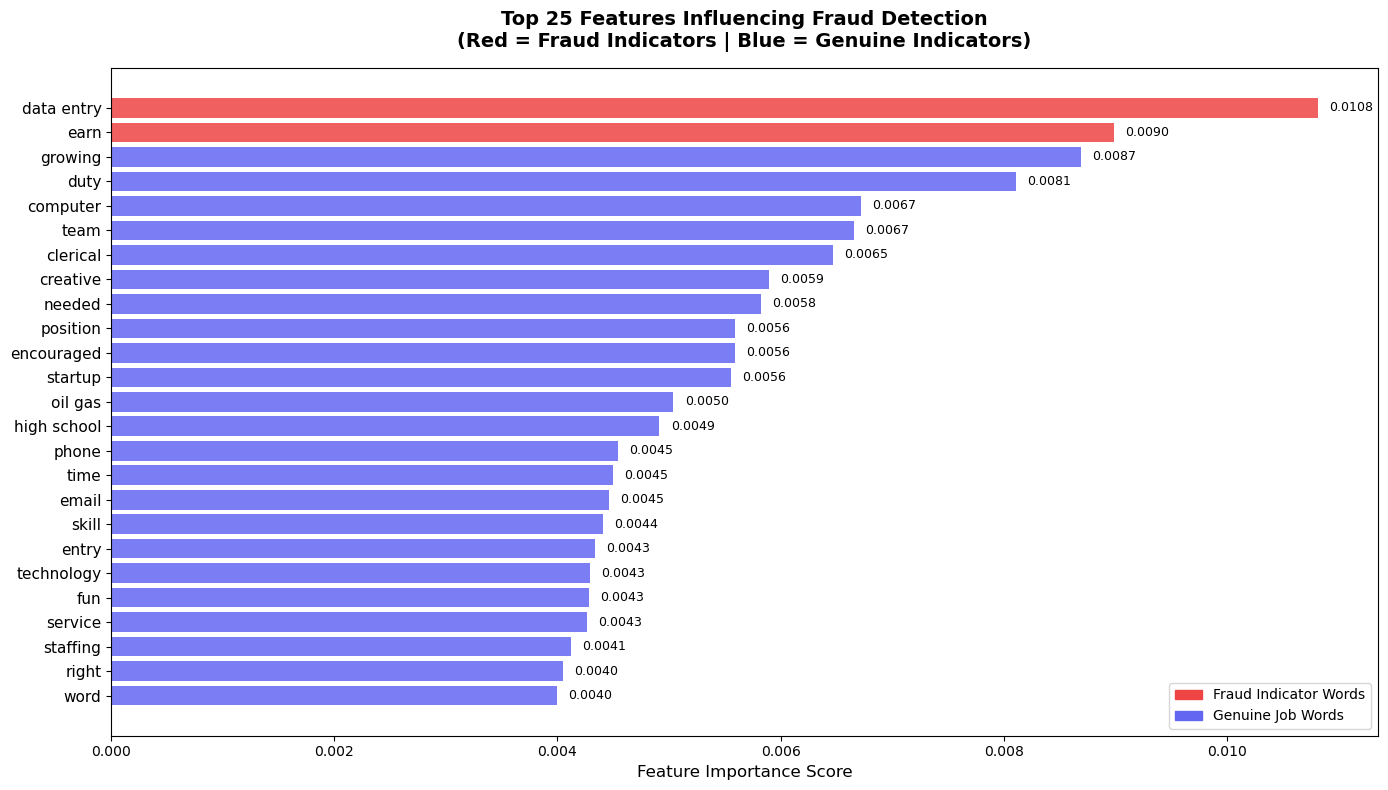

✅ Feature importance chart saved!


In [1]:
# =============================================
# FEATURE IMPORTANCE - Top words causing FRAUD
# =============================================

import matplotlib.pyplot as plt
import numpy as np
import joblib
import pandas as pd

# Load model and vectorizer
rf_model = joblib.load('dataset/model_rf_smote.pkl')
tfidf    = joblib.load('dataset/tfidf_vectorizer.pkl')

# Get feature importances from Random Forest
feature_names  = tfidf.get_feature_names_out()
importances    = rf_model.feature_importances_
top_indices    = importances.argsort()[-25:][::-1]
top_features   = [feature_names[i] for i in top_indices]
top_importance = [importances[i] for i in top_indices]

# Color code — red for fraud-linked, blue for genuine-linked
fraud_words   = ['fee','registration','work home','earn','daily',
                 'immediate','urgent','whatsapp','data entry',
                 'part time','payment','send','money']
colors = ['#ef4444' if any(fw in f for fw in fraud_words) 
          else '#6366f1' for f in top_features]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_features)), 
               top_importance, color=colors, alpha=0.85)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=11)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 25 Features Influencing Fraud Detection\n'
             '(Red = Fraud Indicators | Blue = Genuine Indicators)',
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, top_importance):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#ef4444', label='Fraud Indicator Words'),
          Patch(color='#6366f1', label='Genuine Job Words')]
ax.legend(handles=legend, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")

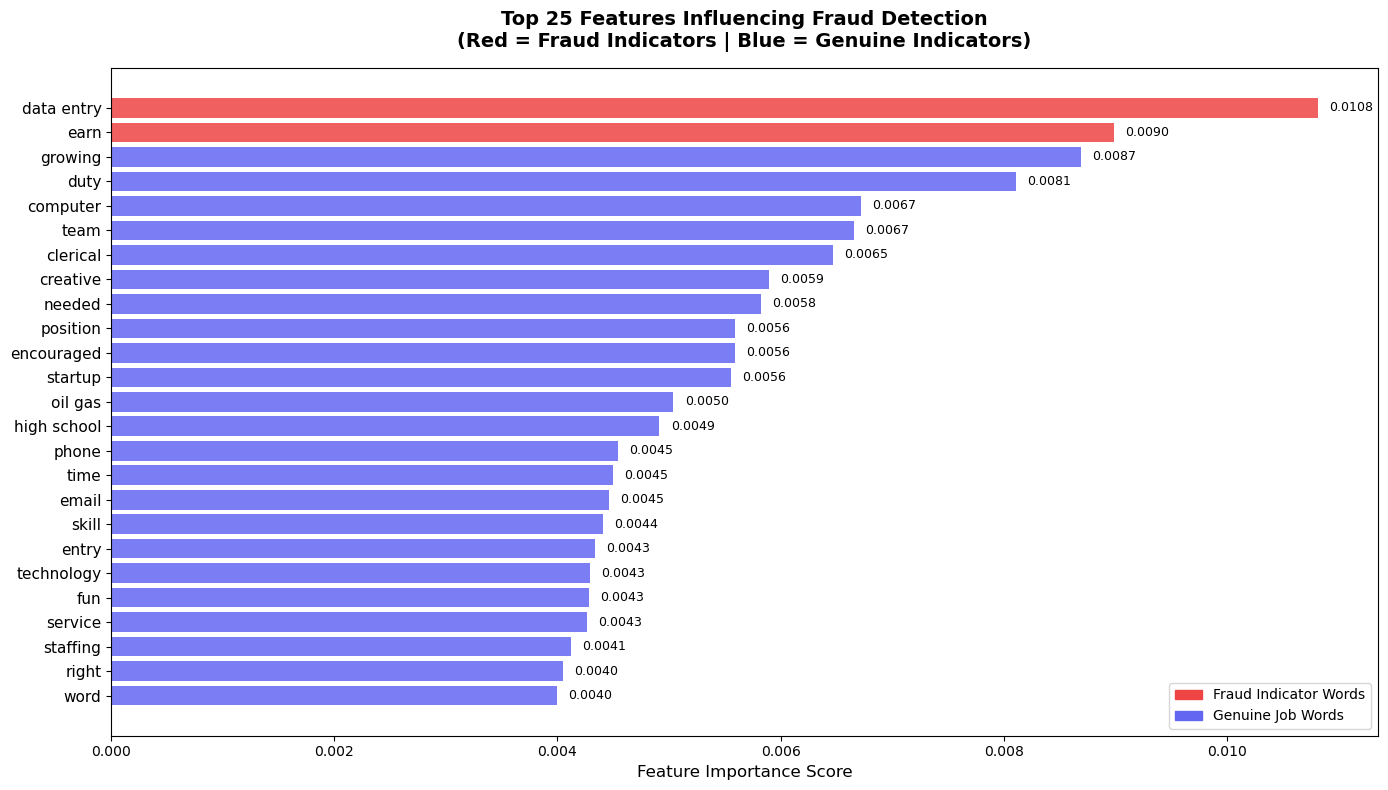

✅ Feature importance chart saved!


In [2]:
# =============================================
# FEATURE IMPORTANCE - Top words causing FRAUD
# This is PhD-level explainability!
# =============================================

import matplotlib.pyplot as plt
import numpy as np
import joblib
import pandas as pd

# Load model and vectorizer
rf_model = joblib.load('dataset/model_rf_smote.pkl')
tfidf    = joblib.load('dataset/tfidf_vectorizer.pkl')

# Get feature importances from Random Forest
feature_names  = tfidf.get_feature_names_out()
importances    = rf_model.feature_importances_
top_indices    = importances.argsort()[-25:][::-1]
top_features   = [feature_names[i] for i in top_indices]
top_importance = [importances[i] for i in top_indices]

# Color code — red for fraud-linked, blue for genuine-linked
fraud_words   = ['fee','registration','work home','earn','daily',
                 'immediate','urgent','whatsapp','data entry',
                 'part time','payment','send','money']
colors = ['#ef4444' if any(fw in f for fw in fraud_words) 
          else '#6366f1' for f in top_features]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_features)), 
               top_importance, color=colors, alpha=0.85)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=11)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 25 Features Influencing Fraud Detection\n'
             '(Red = Fraud Indicators | Blue = Genuine Indicators)',
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, top_importance):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#ef4444', label='Fraud Indicator Words'),
          Patch(color='#6366f1', label='Genuine Job Words')]
ax.legend(handles=legend, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")